In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("telco_churn_clean.csv")

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.shape

(7043, 21)

In [13]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [19]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [23]:
df.dropna(inplace=True)

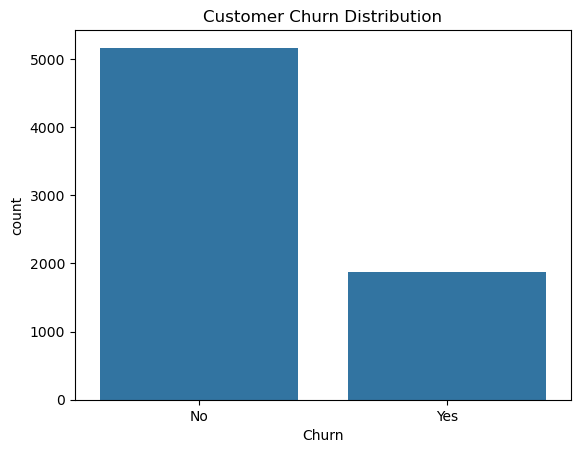

In [25]:
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

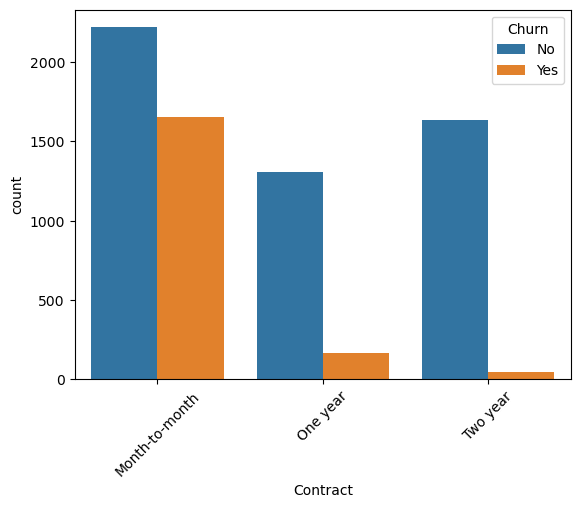

In [27]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.xticks(rotation=45)

plt.show()

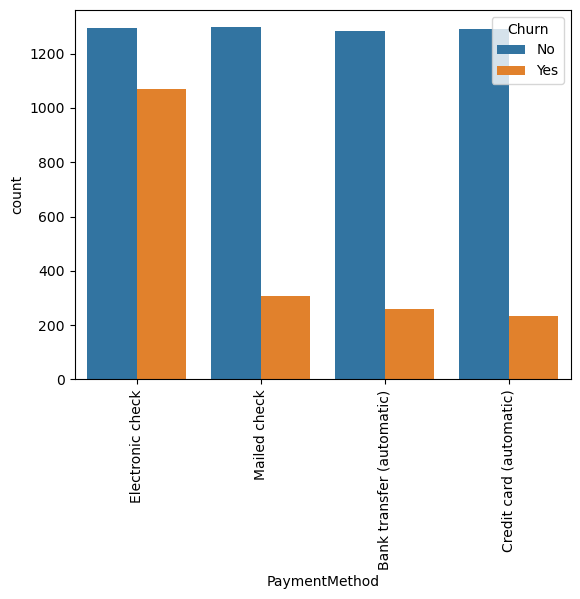

In [29]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.xticks(rotation=90)

plt.show()

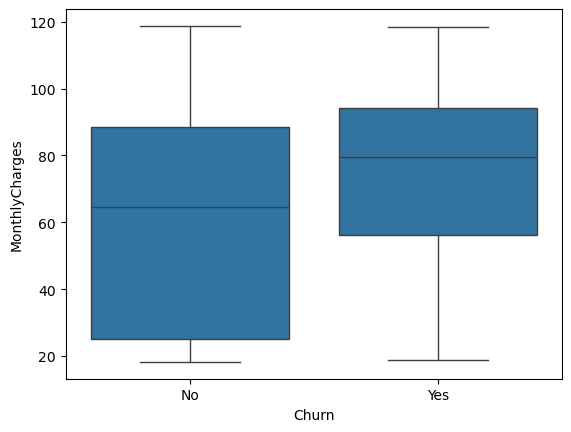

In [31]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.show()

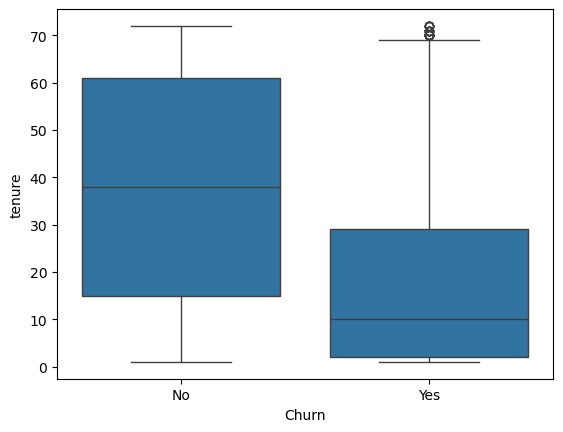

In [33]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.show()

In [35]:
##PHASE — BUILD CHURN PREDICTION MODEL##

In [37]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [39]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True


In [41]:
X = df_encoded.drop('Churn_Yes', axis=1)

y = df_encoded['Churn_Yes']

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [47]:
y_pred = model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7896233120113717


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.82      0.92      0.86      1033
        True       0.66      0.44      0.53       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.70      1407
weighted avg       0.78      0.79      0.77      1407



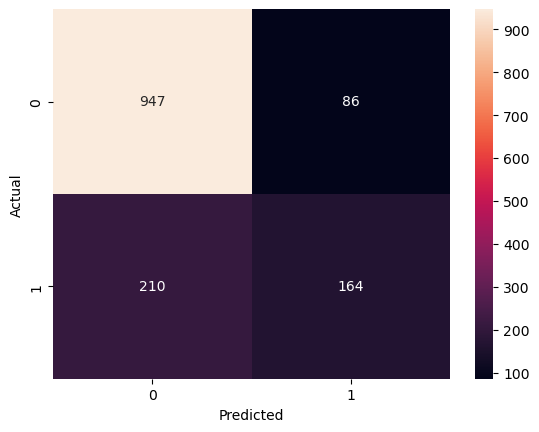

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [55]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
3,TotalCharges,0.102437
1,tenure,0.095978
2,MonthlyCharges,0.083280
7041,InternetService_Fiber optic,0.026298
7050,TechSupport_Yes,0.021811
7056,Contract_Two year,0.021601
7059,PaymentMethod_Electronic check,0.021445
7044,OnlineSecurity_Yes,0.021355
7055,Contract_One year,0.017938
7057,PaperlessBilling_Yes,0.017083


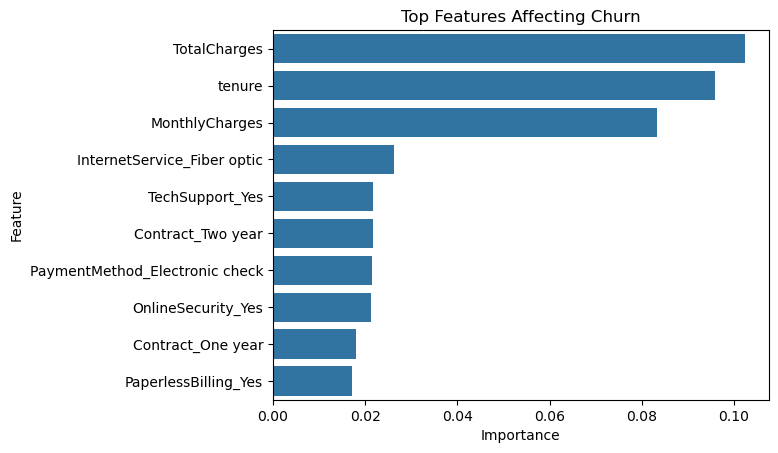

In [57]:
top_features = importance.head(10)

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top Features Affecting Churn")

plt.show()

In [59]:
##Observation:
##Customers with month-to-month contracts are more likely to churn.
#Observation:
#Customers with shorter tenure show higher churn probability.
#Observation:
#Higher monthly charges increase churn risk.

In [61]:
#PHASE — CHURN RISK SCORE

In [63]:
probabilities = model.predict_proba(X_test)

In [65]:
risk_score = probabilities[:,1] * 100

In [67]:
def risk_level(score):
    if score < 30:
        return "Low"
    elif score < 70:
        return "Medium"
    else:
        return "High"

In [69]:
risk_categories = [risk_level(score) for score in risk_score]

In [71]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'RiskScore': risk_score,
    'RiskLevel': risk_categories
})

results.head()

,Actual,Predicted,RiskScore,RiskLevel
2481,False,False,0.0,Low
6784,False,False,4.0,Low
6125,True,True,52.0,Medium
3052,False,False,4.0,Low
4099,False,False,25.0,Low


In [73]:
#PHASE — CHURN PLAYBOOK

In [75]:
def recommend_action(risk):

    if risk == "High":
        return "Assign support manager"

    elif risk == "Medium":
        return "Send retention email"

    else:
        return "Normal engagement"

In [77]:
results['RecommendedAction'] = results['RiskLevel'].apply(
    recommend_action
)

results.head()

,Actual,Predicted,RiskScore,RiskLevel,RecommendedAction
2481,False,False,0.0,Low,Normal engagement
6784,False,False,4.0,Low,Normal engagement
6125,True,True,52.0,Medium,Send retention email
3052,False,False,4.0,Low,Normal engagement
4099,False,False,25.0,Low,Normal engagement


In [79]:
results.to_csv("results.csv", index=False)

In [81]:
df.to_csv("cleaned_churn_data.csv", index=False)

In [94]:
import os

os.getcwd()

'C:\\Users\\pawar'

In [96]:
sample_customer = X_test.iloc[[0]]

In [98]:
model.predict(sample_customer)

array([False])

In [100]:
model.predict_proba(sample_customer)

array([[1., 0.]])

In [102]:
manual_customer = {
    'SeniorCitizen': 0,
    'tenure': 2,
    'MonthlyCharges': 95,
    'TotalCharges': 200,
}

In [104]:
test_customer = X_test.iloc[[0]].copy()

In [106]:
test_customer['tenure'] = 1

test_customer['MonthlyCharges'] = 100

In [108]:
test_customer['Contract_Two year'] = 0
test_customer['Contract_One year'] = 0

In [110]:
prediction = model.predict(test_customer)

print(prediction)

[False]


In [112]:
probability = model.predict_proba(test_customer)

print(probability)

[[0.84 0.16]]


In [114]:
risk_score = probability[0][1] * 100

print("Risk Score:", risk_score)

Risk Score: 16.0


In [116]:
if prediction[0] == 1:
    print("Customer is likely to churn")

else:
    print("Customer is not likely to churn")

Customer is not likely to churn


In [118]:
if risk_score > 70:
    print("Recommended Action: Assign support manager")

elif risk_score > 40:
    print("Recommended Action: Send retention email")

else:
    print("Recommended Action: Normal engagement")

Recommended Action: Normal engagement


In [83]:
import joblib

joblib.dump(
    model,
    r"C:\Users\pawar\OneDrive\Documents\customer-churn-project\models\churn_model.pkl"
)

['C:\\Users\\pawar\\OneDrive\\Documents\\customer-churn-project\\models\\churn_model.pkl']

In [138]:
import sklearn

print(sklearn.__version__)

1.3.2


In [142]:
pip install scikit-learn==1.6.1

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB 163.8 kB/s eta 0:01:08
   ---------------------------------------- 0.0/11.1 MB 163.8 kB/s eta 0:01:08
   ---------------------------------------- 0.1/11.1 MB 280.5 kB/s eta 0:00:40
    --------------------------------------- 0.1/11.1 MB 500.5 kB/s eta 0:00:22
    --------------------------------------- 0.2/11.1 MB 758.5 kB/s eta 0:00:15
   - -------------------------------------- 0.6/11.1 MB 1.5 MB/s eta 0:00:08
   -- ------------------------------------- 0.6/11.1 MB 1.5 MB/s eta 0:00:07
   -- ------------------------------------- 0.8/11.1 MB 1.8 MB/s eta 0:00:06
   --- ------------------------------------ 0.9/11.1 MB 1.9 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/11.1 MB 1.9 MB/s eta 0:00:06
   --- ---